# 1.Importing the Dependencies


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Data Loading and Understanding


In [2]:
df = pd.read_csv("../WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape


(7043, 21)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['TotalCharges'].unique()


<ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

# 3. Data Cleaning


In [7]:
# ============================
# Data Cleaning
# ============================

# Attempt to convert TotalCharges to numeric to identify non-numeric values
temp=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [8]:
# Check how many values failed to convert
print(temp.isnull().sum())

11


In [9]:
# Inspect the rows with failed conversion to understand the cause
df[temp.isnull()]['tenure']

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64

In [10]:
# Fill missing TotalCharges with 0
# These rows correspond to new customers with tenure = 0
df['TotalCharges']=temp.fillna(0)

In [11]:
# Verify no missing values remain
df['TotalCharges'].isnull().sum()

np.int64(0)

In [12]:
# Verify the column type was successfully converted
df['TotalCharges'].dtype

dtype('float64')

In [13]:
df['TotalCharges'].nunique()

6531

In [14]:
# Check whether customerID values are all unique before deciding to drop it
df['customerID'].nunique()

7043

In [15]:
# Drop customerID since it holds no predictive value for the model
df=df.drop('customerID',axis=1)

In [16]:
# Confirm the column was successfully removed
df.shape

(7043, 20)

## 4. Exploratory Data Analysis (EDA)


In [17]:
# ============================
# Exploratory Data Analysis (EDA)
# ============================

# Check the distribution as percentages, to assess class balance
df['Churn'].value_counts(normalize=True)*100


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [18]:
# Inspect unique values in each categorical column
# Helps identify inconsistent labels and determine which columns need encoding
for col in df.select_dtypes(include="object").columns:
   print(col, ":", df[col].unique())


gender : <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines : <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService : <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup : <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies : <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length

C:\Users\dell\AppData\Local\Temp\ipykernel_21480\1916296741.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [19]:
# Analyze churn rate across different contract types
df.groupby('Contract')['Churn'].value_counts(normalize=True)*100


Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64

In [20]:
# Analyze churn rate across different internet service types
df.groupby('InternetService')['Churn'].value_counts(normalize=True)*100


InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64

In [21]:
# Analyze churn rate across different payment methods
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)*100


PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64

In [22]:
# Compare average tenure between customers who churned and those who didn't
df.groupby('Churn')['tenure'].mean()


Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

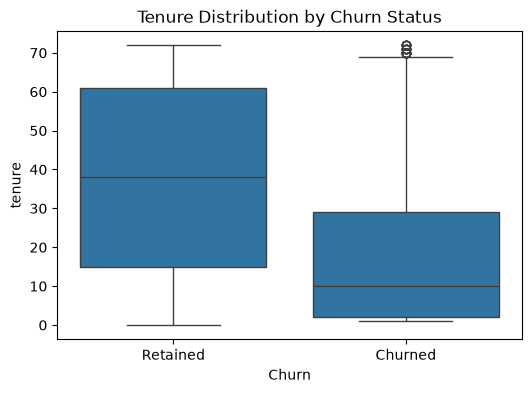

In [23]:
# Box Plot: tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure Distribution by Churn Status')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.show()


In [24]:
# Compare average monthly charges between customers who churned and those who didn't
df.groupby('Churn')['MonthlyCharges'].mean()


Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

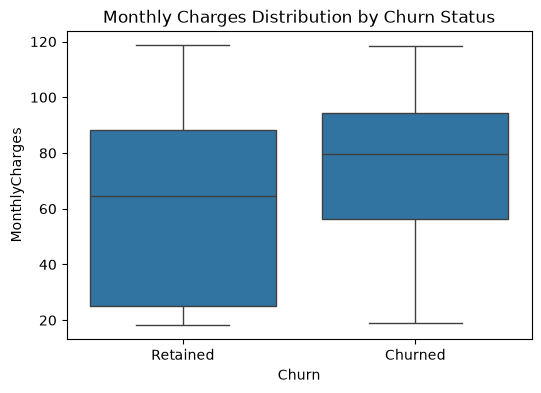

In [25]:
# Box Plot: MonthlyCharges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges Distribution by Churn Status')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.show()


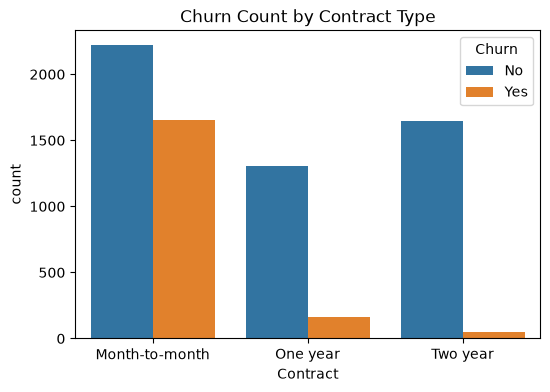

In [26]:
# Visualize the relationship between contract type and churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Count by Contract Type')
plt.show()


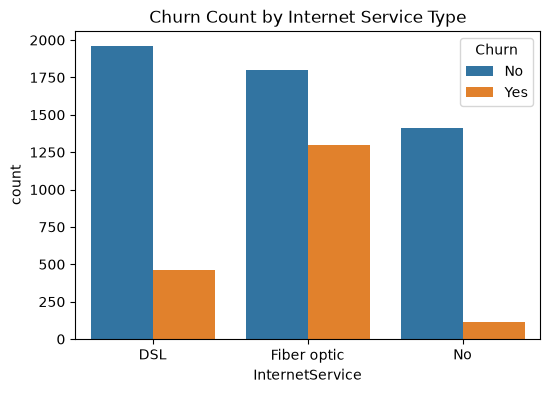

In [27]:
# Visualize the relationship between internet service type and churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn Count by Internet Service Type')
plt.show()


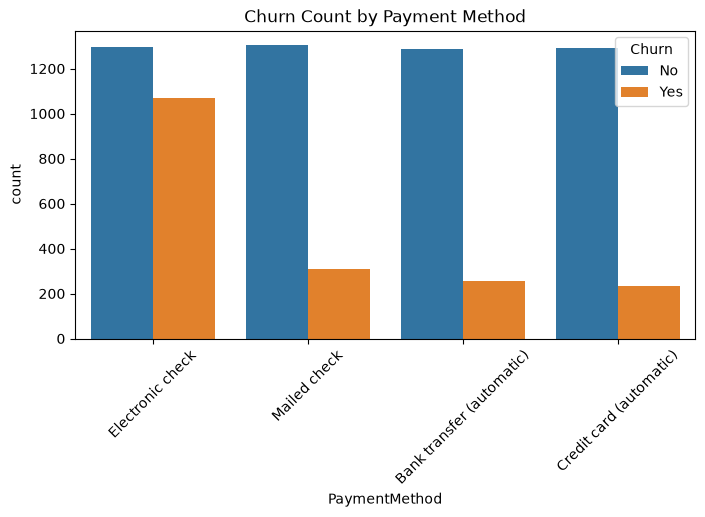

In [28]:
# Visualize the relationship between payment method and churn
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn Count by Payment Method')
plt.xticks(rotation=45)
plt.show()


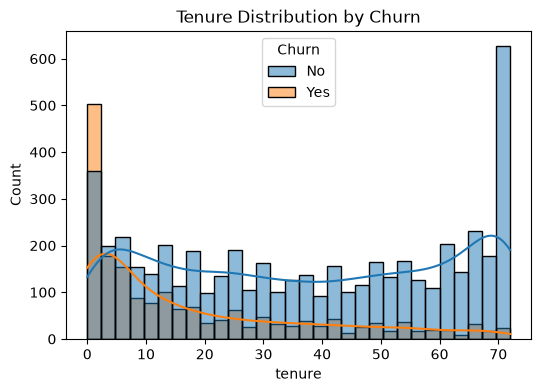

In [29]:
# Visualize how tenure is distributed for churned vs retained customers
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()


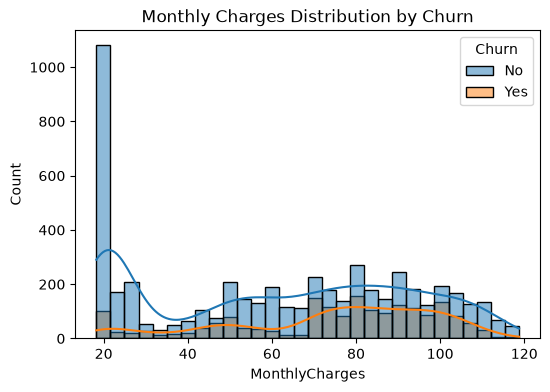

In [30]:
# Visualize how monthly charges are distributed for churned vs retained customers
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.title('Monthly Charges Distribution by Churn')
plt.show()


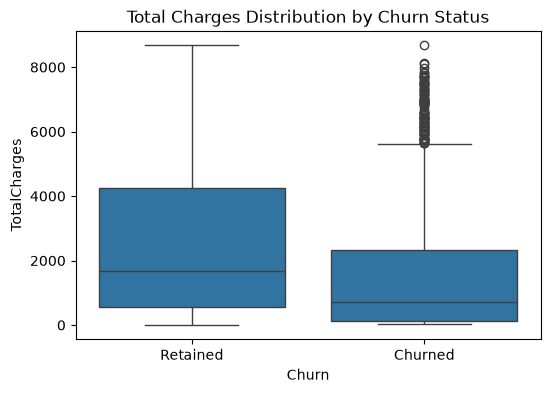

In [31]:
# Box Plot: TotalCharges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges Distribution by Churn Status')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.show()


# 5. Feature Engineering & Preprocessing


In [32]:
# Convert target variable to binary (1 = churned, 0 = retained)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['Churn'].unique()


array([0, 1])

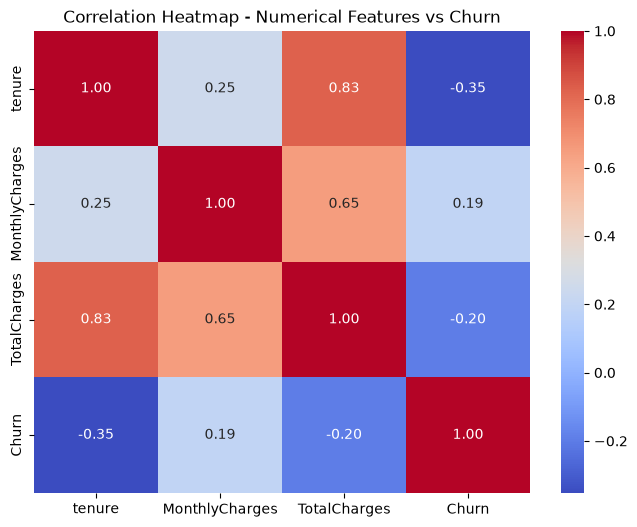

In [33]:
# Correlation Heatmap for numerical features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numerical Features vs Churn')
plt.show()


In [34]:
# Encode simple binary columns (Yes/No) as 1/0
cols_yes_no = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in cols_yes_no:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']].head()


,Partner,Dependents,PhoneService,PaperlessBilling
0,1,0,0,1
1,0,0,1,0
2,0,0,1,1
3,0,0,0,0
4,0,0,1,1


In [35]:
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})


In [36]:
# Encode service-related columns, merging "No internet/phone service"
# into "No" since that information is already captured by InternetService
cols_service = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
mapping = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}

for col in cols_service:
    df[col] = df[col].map(mapping)

df[cols_service].head()


,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,0,1,0,0,0,0
1,0,1,0,1,0,0,0
2,0,1,1,0,0,0,0
3,0,1,0,1,1,0,0
4,0,0,0,0,0,0,0


In [37]:
# One-hot encode categorical columns with more than two categories,
# dropping the first category of each to avoid redundancy
df=pd.get_dummies(df,columns=['InternetService', 'Contract', 'PaymentMethod'],drop_first=True)

df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [38]:
df.shape


(7043, 24)

In [39]:
# Confirm no text (object) columns remain before modeling
df.select_dtypes(include='object').columns


Index([], dtype='str')

In [40]:
import os

# Save the fully processed dataset for the modeling notebook
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/processed_data.csv', index=False)
print('Processed data saved to ../data/processed_data.csv')
print('Shape:', df.shape)


Processed data saved to ../data/processed_data.csv
Shape: (7043, 24)
